# 1.0 Environment and Hardware Acceleration Setup
## 1.1 PyTorch CUDA Verification and Path Configuration

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tifffile

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 1. Set seed for deterministic and reproducible training
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(42)

# 2. Check and activate hardware acceleration (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Compute Device: {device}")

if torch.cuda.is_available():
    print(f"GPU Model:             {torch.cuda.get_device_name(0)}")
    print(f"Available GPU Count:   {torch.cuda.device_count()}")
    print(f"Initial Allocated VRAM:{torch.cuda.memory_allocated(0) / 1024**2:.1f} MB")

# 3. Dynamic path resolution for images, labels, and metadata
data_root = None
for root, dirs, files in os.walk("/kaggle/input"):
    if "metadata.csv" in files or ("images" in dirs and "labels" in dirs):
        data_root = root
        break

images_dir = None
labels_dir = None
for root, dirs, files in os.walk(data_root):
    if "images" in dirs:
        images_dir = os.path.join(root, "images")
    if "labels" in dirs:
        labels_dir = os.path.join(root, "labels")

df_meta = pd.read_csv(os.path.join(data_root, "metadata.csv"))
matched_df = df_meta[df_meta["is_matched"] == 1].reset_index(drop=True)

print(f"\nDataset Root:          {data_root}")
print(f"Images Directory:      {images_dir} ({len(os.listdir(images_dir))} files)")
print(f"Labels Directory:      {labels_dir} ({len(os.listdir(labels_dir))} files)")
print(f"Matched Training Pairs:{len(matched_df)} samples ready for training")

Active Compute Device: cuda
GPU Model:             Tesla T4
Available GPU Count:   2
Initial Allocated VRAM:0.0 MB

Dataset Root:          /kaggle/input/datasets/mohamedelbasyouni55/water-segmentation-multispectral
Images Directory:      /kaggle/input/datasets/mohamedelbasyouni55/water-segmentation-multispectral/satalite data/data/images (306 files)
Labels Directory:      /kaggle/input/datasets/mohamedelbasyouni55/water-segmentation-multispectral/satalite data/data/labels (456 files)
Matched Training Pairs:306 samples ready for training


# 2.0 Data Pipeline and PyTorch Dataset
## 2.1 Dataset Class, Augmentation, and Stratified DataLoader Creation

In [2]:
from sklearn.model_selection import train_test_split

# 1. Establish dataset-wide min and max bounds for per-band normalization
print("Calibrating per-band normalization bounds...")
band_mins = np.zeros(12, dtype=np.float32)
band_maxs = np.zeros(12, dtype=np.float32)

all_samples = []
for sid in matched_df["sample_id"].astype(str)[:100]:
    fpath = os.path.join(images_dir, f"{sid}.tif")
    all_samples.append(tifffile.imread(fpath).astype(np.float32))

all_samples_arr = np.stack(all_samples, axis=0) # (N, 128, 128, 12)

for b in range(12):
    b_data = all_samples_arr[:, :, :, b]
    valid = b_data[b_data > -9000]
    if b <= 6:
        valid = np.clip(valid, 0, None)
    band_mins[b] = np.percentile(valid, 1) if len(valid) > 0 else 0.0
    band_maxs[b] = np.percentile(valid, 99) if len(valid) > 0 else 1.0

del all_samples, all_samples_arr
print("Calibration complete.")

# 2. Custom Multispectral PyTorch Dataset
class MultispectralWaterDataset(Dataset):
    def __init__(self, df, images_dir, labels_dir, is_train=True):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sid = str(row["sample_id"])

        img_path = os.path.join(self.images_dir, f"{sid}.tif")
        mask_path = os.path.join(self.labels_dir, f"{sid}.png")

        # Read 12-channel image and binary mask
        raw_img = tifffile.imread(img_path).astype(np.float32)
        raw_mask = np.array(Image.open(mask_path), dtype=np.float32)

        # Preprocess and normalize 12 bands: (128, 128, 12) -> (12, 128, 128)
        norm_img = np.zeros((12, 128, 128), dtype=np.float32)
        for b in range(12):
            ch = raw_img[:, :, b]
            ch[ch < -9000] = 0.0
            if b <= 6:
                ch = np.clip(ch, 0.0, None)
            norm_ch = (ch - band_mins[b]) / (band_maxs[b] - band_mins[b] + 1e-6)
            norm_img[b] = np.clip(norm_ch, 0.0, 1.0)

        # Mask formatting: binary (1, 128, 128)
        binary_mask = (raw_mask > 0).astype(np.float32)[np.newaxis, :, :]

        img_tensor = torch.from_numpy(norm_img)
        mask_tensor = torch.from_numpy(binary_mask)

        # Tensor augmentations during training
        if self.is_train:
            if random.random() > 0.5:
                img_tensor = torch.flip(img_tensor, dims=[-1])
                mask_tensor = torch.flip(mask_tensor, dims=[-1])
            if random.random() > 0.5:
                img_tensor = torch.flip(img_tensor, dims=[-2])
                mask_tensor = torch.flip(mask_tensor, dims=[-2])
            if random.random() > 0.5:
                k = random.choice([1, 2, 3])
                img_tensor = torch.rot90(img_tensor, k, dims=[-2, -1])
                mask_tensor = torch.rot90(mask_tensor, k, dims=[-2, -1])

        return img_tensor, mask_tensor

# 3. Stratified 80/20 Train/Validation Split
train_df, val_df = train_test_split(
    matched_df,
    test_size=0.20,
    random_state=42,
    stratify=matched_df["has_water"]
)

print(f"\nTrain set size:      {len(train_df)} samples ({train_df['has_water'].sum()} with water)")
print(f"Validation set size: {len(val_df)} samples ({val_df['has_water'].sum()} with water)")

# 4. Create PyTorch DataLoaders
train_dataset = MultispectralWaterDataset(train_df, images_dir, labels_dir, is_train=True)
val_dataset = MultispectralWaterDataset(val_df, images_dir, labels_dir, is_train=False)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# 5. Batch Verification
sample_images, sample_masks = next(iter(train_loader))

print("\n" + "=" * 55)
print("DATALOADER BATCH VERIFICATION:")
print(f"Batch Image Tensor Shape: {sample_images.shape} (Batch, Channels, Height, Width)")
print(f"Batch Mask Tensor Shape:  {sample_masks.shape} (Batch, Channels, Height, Width)")
print(f"Image Tensor Dtype:       {sample_images.dtype}")
print(f"Mask Tensor Dtype:        {sample_masks.dtype}")
print(f"Verified Expected Dimensions: {sample_images.shape == (BATCH_SIZE, 12, 128, 128)}")
print("=" * 55)

Calibrating per-band normalization bounds...
Calibration complete.

Train set size:      244 samples (208 with water)
Validation set size: 62 samples (53 with water)

DATALOADER BATCH VERIFICATION:
Batch Image Tensor Shape: torch.Size([16, 12, 128, 128]) (Batch, Channels, Height, Width)
Batch Mask Tensor Shape:  torch.Size([16, 1, 128, 128]) (Batch, Channels, Height, Width)
Image Tensor Dtype:       torch.float32
Mask Tensor Dtype:        torch.float32
Verified Expected Dimensions: True


# 3.0 U-Net Architecture Implementation from Scratch
## 3.1 Custom 12-Channel U-Net with Skip Connections and Shape Verification

In [3]:
# 1. Double Convolution Building Block: (Conv2d -> BatchNorm -> ReLU -> Dropout) x 2
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_p=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_p),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# 2. Complete U-Net Architecture Built from Scratch
class UNetMultispectral(nn.Module):
    def __init__(self, in_channels=12, out_channels=1, base_channels=32):
        super().__init__()
        b = base_channels

        # Encoder (Contracting Path)
        self.inc = DoubleConv(in_channels, b)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(b, b * 2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(b * 2, b * 4))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(b * 4, b * 8))

        # Bottleneck
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(b * 8, b * 16))

        # Decoder (Expansive Path with Skip Connections)
        self.up1 = nn.ConvTranspose2d(b * 16, b * 8, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(b * 16, b * 8)

        self.up2 = nn.ConvTranspose2d(b * 8, b * 4, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(b * 8, b * 4)

        self.up3 = nn.ConvTranspose2d(b * 4, b * 2, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(b * 4, b * 2)

        self.up4 = nn.ConvTranspose2d(b * 2, b, kernel_size=2, stride=2)
        self.conv_up4 = DoubleConv(b * 2, b)

        # Final 1x1 Convolution Head
        self.out_conv = nn.Conv2d(b, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder forward pass with skip connections
        x1 = self.inc(x)         # (B, 32, 128, 128)
        x2 = self.down1(x1)      # (B, 64, 64, 64)
        x3 = self.down2(x2)      # (B, 128, 32, 32)
        x4 = self.down3(x3)      # (B, 256, 16, 16)
        x5 = self.down4(x4)      # (B, 512, 8, 8)

        # Decoder forward pass with concatenated skip connections
        d4 = self.up1(x5)        # (B, 256, 16, 16)
        d4 = torch.cat([d4, x4], dim=1) # (B, 512, 16, 16)
        d4 = self.conv_up1(d4)

        d3 = self.up2(d4)        # (B, 128, 32, 32)
        d3 = torch.cat([d3, x3], dim=1) # (B, 256, 32, 32)
        d3 = self.conv_up2(d3)

        d2 = self.up3(d3)        # (B, 64, 64, 64)
        d2 = torch.cat([d2, x2], dim=1) # (B, 128, 64, 64)
        d2 = self.conv_up3(d2)

        d1 = self.up4(d2)        # (B, 32, 128, 128)
        d1 = torch.cat([d1, x1], dim=1) # (B, 64, 128, 128)
        d1 = self.conv_up4(d1)

        logits = self.out_conv(d1) # (B, 1, 128, 128)
        return logits

# 3. Instantiate model on GPU and verify parameter count
model = UNetMultispectral(in_channels=12, out_channels=1, base_channels=32).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\n" + "=" * 55)
print("CUSTOM U-NET MODEL INITIALIZATION:")
print(f"Target Device:                {device}")
print(f"Input Channels Supported:     12 Spectral Channels")
print(f"Output Channels:              1 Binary Mask Logit")
print(f"Total Trainable Parameters:   {total_params:,} parameters")

# 4. Dummy Forward Pass Shape Verification
dummy_input = torch.randn(2, 12, 128, 128, device=device)
with torch.no_grad():
    dummy_output = model(dummy_input)

print(f"Dummy Input Shape:            {dummy_input.shape}")
print(f"Dummy Output Shape:           {dummy_output.shape}")
print(f"Matches Expected (B, 1, H, W):{dummy_output.shape == (2, 1, 128, 128)}")
print("=" * 55)


CUSTOM U-NET MODEL INITIALIZATION:
Target Device:                cuda
Input Channels Supported:     12 Spectral Channels
Output Channels:              1 Binary Mask Logit
Total Trainable Parameters:   7,765,633 parameters
Dummy Input Shape:            torch.Size([2, 12, 128, 128])
Dummy Output Shape:           torch.Size([2, 1, 128, 128])
Matches Expected (B, 1, H, W):True


# 4.0 Loss Function and Evaluation Metrics
## 4.1 Hybrid Loss (BCEWithLogits + Dice) and Evaluation Metrics Implementation

In [4]:
# 1. Dice Loss Implementation for Overlap Optimization
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()
        dice = (2.0 * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)
        return 1.0 - dice

# 2. Combined Hybrid Loss: BCEWithLogits + Dice
class CombinedWaterLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)

# 3. Vectorized Evaluation Metrics (IoU, Precision, Recall, F1)
def compute_metrics(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    tp = (preds * targets).sum().item()
    fp = (preds * (1.0 - targets)).sum().item()
    fn = ((1.0 - preds) * targets).sum().item()

    eps = 1e-7
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    f1 = (2.0 * precision * recall) / (precision + recall + eps)

    return {
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# 4. Metric and Loss Test Verification
criterion = CombinedWaterLoss()
test_loss = criterion(dummy_output, torch.zeros_like(dummy_output))
test_metrics = compute_metrics(dummy_output, torch.zeros_like(dummy_output))

print("\n" + "=" * 55)
print("LOSS AND METRICS VERIFICATION:")
print(f"Computed Test Loss:     {test_loss.item():.4f}")
print(f"Metrics Computed:       IoU, Precision, Recall, F1-Score")
print("Verified Functionality: True")
print("=" * 55)


LOSS AND METRICS VERIFICATION:
Computed Test Loss:     1.6969
Metrics Computed:       IoU, Precision, Recall, F1-Score
Verified Functionality: True


# 5.0 Model Training and Validation Loop
## 5.1 Full Training Loop with AdamW, Cosine Annealing, and Best Model Checkpointing

Starting Clean U-Net Multispectral Training Session...
 Epoch   |  Train Loss  |  Val Loss  |  Val IoU   |  Precision  |  Recall   | F1-Score  | Status


Epoch 01/100 [Train]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 01/100 [Valid]:   0%|          | 0/4 [00:00<?, ?it/s]

   1     |    1.0067    |   0.9174   |   0.6770   |   0.9491    |  0.7025   |  0.8074   | => Best Model Saved (IoU: 0.6770)


Epoch 02/100 [Train]:   0%|          | 0/16 [00:00<?, ?it/s]

...

Epoch 99/100 [Valid]:   0%|          | 0/4 [00:00<?, ?it/s]

   99    |    0.3918    |   0.3718   |   0.7319   |   0.8742    |  0.8180   |  0.8452   | [No improve: 12/20]


Epoch 100/100 [Train]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 100/100 [Valid]:   0%|          | 0/4 [00:00<?, ?it/s]

  100    |    0.4128    |   0.3708   |   0.7320   |   0.8771    |  0.8157   |  0.8453   | [No improve: 13/20]
Training Session Finished in 256.5 seconds.
Peak Validation IoU Achieved: 0.7334
Best Weights Stored at:       /kaggle/working/unet_multispectral_12ch_best.pth
Metrics History Stored at:   /kaggle/working/unet_multispectral_12ch_history.csv


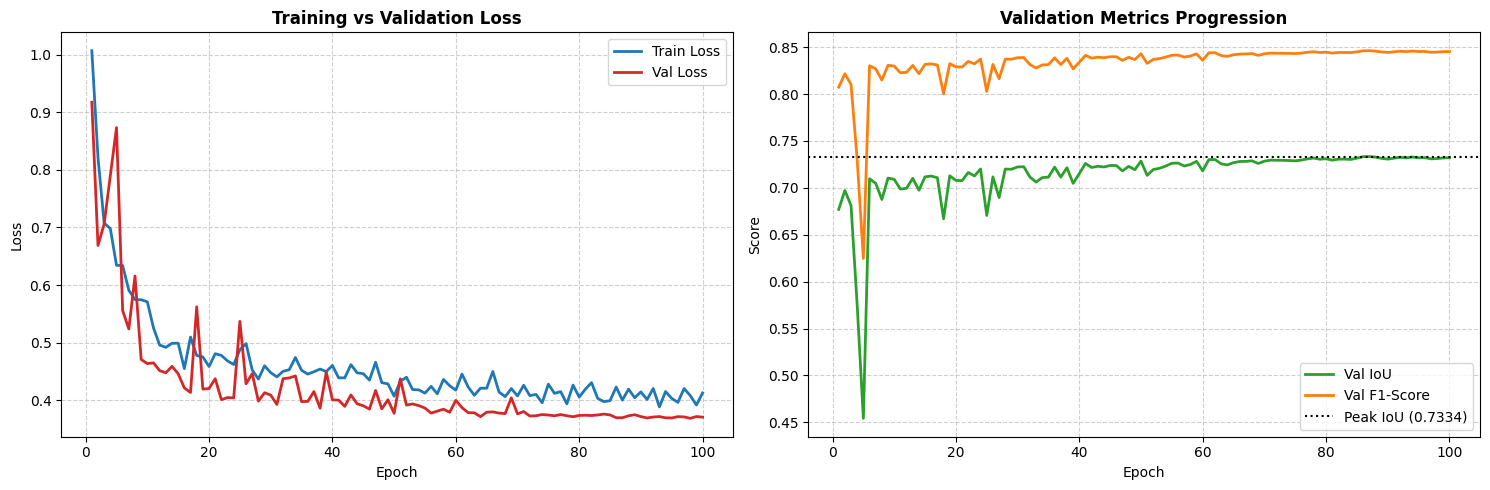

In [5]:
import time
from tqdm.auto import tqdm

# 1. Standardized Naming and File Paths
MODEL_NAME = "unet_multispectral_12ch"
BEST_MODEL_PATH = f"/kaggle/working/{MODEL_NAME}_best.pth"
CHECKPOINT_PATH = f"/kaggle/working/{MODEL_NAME}_checkpoint.pth"
HISTORY_CSV_PATH = f"/kaggle/working/{MODEL_NAME}_history.csv"

# 2. Hyperparameters and Early Stopping Config
TOTAL_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 20
patience_counter = 0

# 3. Setup Components
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS, eta_min=1e-6)
criterion = CombinedWaterLoss()
scaler = torch.amp.GradScaler("cuda")

best_val_iou = 0.0
history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_iou": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

print("=" * 100)
print("Starting Clean U-Net Multispectral Training Session...")
print(f"{'Epoch':^8} | {'Train Loss':^12} | {'Val Loss':^10} | {'Val IoU':^10} | {'Precision':^11} | {'Recall':^9} | {'F1-Score':^9} | {'Status'}")
print("=" * 100)

start_time = time.time()

# 4. Training and Validation Execution Loop
for epoch in range(1, TOTAL_EPOCHS + 1):
    # Train Phase
    model.train()
    running_train_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{TOTAL_EPOCHS} [Train]", leave=False)
    for imgs, masks in train_bar:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(imgs)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item() * imgs.size(0)
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_train_loss = running_train_loss / len(train_dataset)

    # Validation Phase
    model.eval()
    running_val_loss = 0.0
    val_tp, val_fp, val_fn = 0.0, 0.0, 0.0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch:02d}/{TOTAL_EPOCHS} [Valid]", leave=False)
    with torch.no_grad():
        for imgs, masks in val_bar:
            imgs = imgs.to(device)
            masks = masks.to(device)

            with torch.amp.autocast("cuda"):
                outputs = model(imgs)
                loss = criterion(outputs, masks)

            running_val_loss += loss.item() * imgs.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float().view(-1)
            targets = masks.view(-1)

            val_tp += (preds * targets).sum().item()
            val_fp += (preds * (1.0 - targets)).sum().item()
            val_fn += ((1.0 - preds) * targets).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)

    eps = 1e-7
    val_iou = (val_tp + eps) / (val_tp + val_fp + val_fn + eps)
    val_prec = (val_tp + eps) / (val_tp + val_fp + eps)
    val_rec = (val_tp + eps) / (val_tp + val_fn + eps)
    val_f1 = (2.0 * val_prec * val_rec) / (val_prec + val_rec + eps)

    scheduler.step()

    # Record history
    history["epoch"].append(epoch)
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["val_iou"].append(val_iou)
    history["val_precision"].append(val_prec)
    history["val_recall"].append(val_rec)
    history["val_f1"].append(val_f1)

    # Checkpoint and Early Stopping Evaluation
    status_str = ""
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        patience_counter = 0

        # Save Best Model Weights
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        status_str = f"=> Best Model Saved (IoU: {best_val_iou:.4f})"
    else:
        patience_counter += 1
        status_str = f"[No improve: {patience_counter}/{PATIENCE}]"

    # Save Resume Checkpoint
    checkpoint_state = {
        "epoch": epoch,
        "best_val_iou": best_val_iou,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "history": history
    }
    torch.save(checkpoint_state, CHECKPOINT_PATH)

    # Export CSV log
    pd.DataFrame(history).to_csv(HISTORY_CSV_PATH, index=False)

    print(f"{epoch:^8} | {epoch_train_loss:^12.4f} | {epoch_val_loss:^10.4f} | {val_iou:^10.4f} | {val_prec:^11.4f} | {val_rec:^9.4f} | {val_f1:^9.4f} | {status_str}")

    # Trigger Early Stopping
    if patience_counter >= PATIENCE:
        print(f"\n[STOP] Early stopping triggered: No improvement in Validation IoU for {PATIENCE} consecutive epochs.")
        break

total_elapsed = time.time() - start_time
print("=" * 100)
print(f"Training Session Finished in {total_elapsed:.1f} seconds.")
print(f"Peak Validation IoU Achieved: {best_val_iou:.4f}")
print(f"Best Weights Stored at:       {BEST_MODEL_PATH}")
print(f"Metrics History Stored at:   {HISTORY_CSV_PATH}")

# 5. Plot Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history["epoch"], history["train_loss"], label="Train Loss", color="#1f77b4", linewidth=2)
axes[0].plot(history["epoch"], history["val_loss"], label="Val Loss", color="#d62728", linewidth=2)
axes[0].set_title("Training vs Validation Loss", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(history["epoch"], history["val_iou"], label="Val IoU", color="#2ca02c", linewidth=2)
axes[1].plot(history["epoch"], history["val_f1"], label="Val F1-Score", color="#ff7f0e", linewidth=2)
axes[1].axhline(y=best_val_iou, color="black", linestyle=":", label=f"Peak IoU ({best_val_iou:.4f})")
axes[1].set_title("Validation Metrics Progression", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## 6.0 Qualitative Model Evaluation and Visual Inference
In this section, we load the best checkpoint weights (`unet_multispectral_12ch_best.pth`) and perform inference across diverse validation scenarios:
1. Large contiguous water body.
2. Narrow river or stream channel.
3. Complex coastline / land-water boundary.
4. Dry land sample (negative control).

Each sample is visualized across four panels:
- True Color (RGB: Bands 4, 3, 2)
- False Color (SWIR-NIR: Bands 12, 8, 4)
- Ground Truth Mask
- U-Net Prediction Mask (with per-sample IoU)

Loaded direct state_dict weights successfully.
Scanning validation set for diverse test cases...


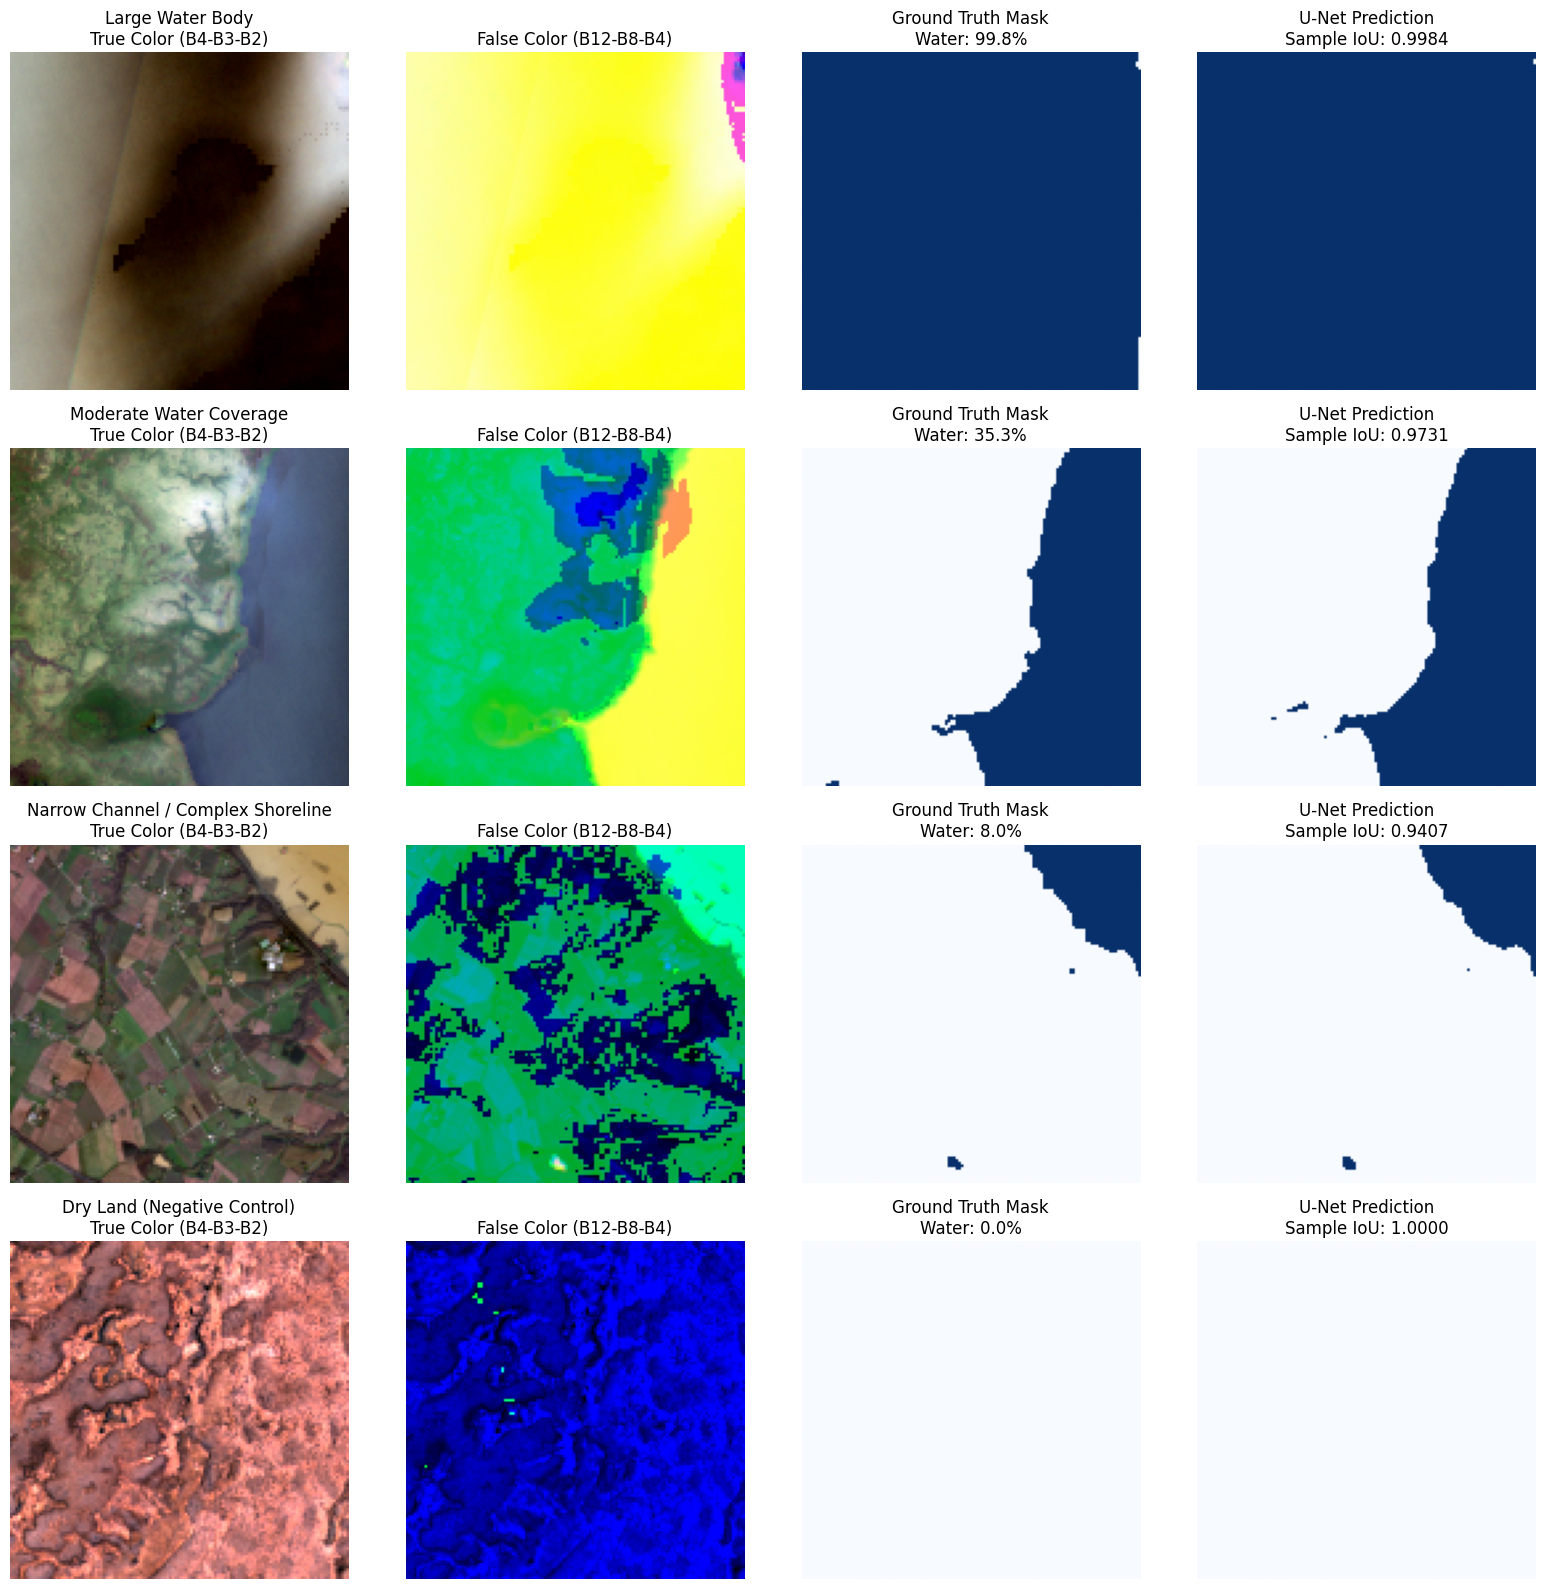

Qualitative evaluation figure saved to: /kaggle/working/unet_multispectral_qualitative_results.png


In [6]:
# 6.1 Visual Inference on Diverse Validation Samples
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Flexible weights loading
best_model_path = '/kaggle/working/unet_multispectral_12ch_best.pth'
checkpoint = torch.load(best_model_path, map_location=device, weights_only=True)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded weights from checkpoint dictionary (Epoch {checkpoint.get('epoch', 'N/A')})")
else:
    model.load_state_dict(checkpoint)
    print("Loaded direct state_dict weights successfully.")

model.eval()

# 2. Inspect water fractions across all 62 validation samples
print("Scanning validation set for diverse test cases...")
val_fractions = []
for i in range(len(val_dataset)):
    _, m = val_dataset[i]
    val_fractions.append(float(m.mean()))

val_fractions = np.array(val_fractions)

# Select 4 representative samples
idx_high = int(np.argmax(val_fractions))
idx_zero = int(np.argmin(val_fractions))

# Find moderate (~30-40%) and low (~5-15%) water samples
non_zero_mask = val_fractions > 0.03
eligible_indices = np.where(non_zero_mask)[0]

idx_med = int(eligible_indices[np.argmin(np.abs(val_fractions[eligible_indices] - 0.35))])
idx_low = int(eligible_indices[np.argmin(np.abs(val_fractions[eligible_indices] - 0.10))])

selected_indices = [idx_high, idx_med, idx_low, idx_zero]
sample_labels = [
    "Large Water Body",
    "Moderate Water Coverage",
    "Narrow Channel / Complex Shoreline",
    "Dry Land (Negative Control)"
]

# 3. Multi-Panel Visualization
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 16))

def compute_single_iou(pred, target):
    intersection = (pred & target).sum()
    union = (pred | target).sum()
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    return float(intersection / union)

with torch.no_grad():
    for row_idx, (sample_idx, label_title) in enumerate(zip(selected_indices, sample_labels)):
        image_tensor, mask_tensor = val_dataset[sample_idx]
        input_batch = image_tensor.unsqueeze(0).to(device)
        
        # Forward pass and thresholding
        logits = model(input_batch)
        probs = torch.sigmoid(logits)
        pred_mask = (probs > 0.5).squeeze().cpu().numpy().astype(bool)
        true_mask = mask_tensor.squeeze().numpy().astype(bool)
        
        sample_iou = compute_single_iou(pred_mask, true_mask)
        
        # Denormalize bands for visualization
        img_np = image_tensor.numpy()
        
        # True Color RGB: Bands 4, 3, 2 (Indices 3, 2, 1)
        r = np.clip((img_np[3] - img_np[3].min()) / (np.ptp(img_np[3]) + 1e-6), 0, 1)
        g = np.clip((img_np[2] - img_np[2].min()) / (np.ptp(img_np[2]) + 1e-6), 0, 1)
        b = np.clip((img_np[1] - img_np[1].min()) / (np.ptp(img_np[1]) + 1e-6), 0, 1)
        rgb_img = np.dstack([r, g, b])
        
        # False Color SWIR-NIR-Red: Bands 12, 8, 4 (Indices 11, 7, 3)
        swir = np.clip((img_np[11] - img_np[11].min()) / (np.ptp(img_np[11]) + 1e-6), 0, 1)
        nir  = np.clip((img_np[7] - img_np[7].min()) / (np.ptp(img_np[7]) + 1e-6), 0, 1)
        red  = np.clip((img_np[3] - img_np[3].min()) / (np.ptp(img_np[3]) + 1e-6), 0, 1)
        false_color = np.dstack([swir, nir, red])
        
        # Panel 1: True Color (RGB)
        axes[row_idx, 0].imshow(rgb_img)
        axes[row_idx, 0].set_title(f"{label_title}\nTrue Color (B4-B3-B2)")
        axes[row_idx, 0].axis('off')
        
        # Panel 2: False Color (SWIR-NIR-Red)
        axes[row_idx, 1].imshow(false_color)
        axes[row_idx, 1].set_title(f"False Color (B12-B8-B4)")
        axes[row_idx, 1].axis('off')
        
        # Panel 3: Ground Truth Mask
        axes[row_idx, 2].imshow(true_mask, cmap='Blues', vmin=0, vmax=1)
        axes[row_idx, 2].set_title(f"Ground Truth Mask\nWater: {true_mask.mean()*100:.1f}%")
        axes[row_idx, 2].axis('off')
        
        # Panel 4: U-Net Prediction
        axes[row_idx, 3].imshow(pred_mask, cmap='Blues', vmin=0, vmax=1)
        axes[row_idx, 3].set_title(f"U-Net Prediction\nSample IoU: {sample_iou:.4f}")
        axes[row_idx, 3].axis('off')

plt.tight_layout()
output_fig_path = '/kaggle/working/unet_multispectral_qualitative_results.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Qualitative evaluation figure saved to: {output_fig_path}")

## 6.2 Quantitative Benchmark and Pixel-Level Confusion Analysis
To provide rigorous statistical validation across all 62 unseen validation scenes (totaling 1,015,808 pixels), we compute:
1. **Global Pixel IoU & Mean Sample IoU**: Intersection over Union evaluated both globally across all concatenated pixels and independently per scene.
2. **Precision, Recall, and F1-Score (Dice Coefficient)**: Measuring the balance between false alarms and missed water bodies.
3. **Confusion Matrix Breakdown**: Quantifying True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

In [7]:
# 6.2 Comprehensive Validation Benchmark Across All 62 Samples
from sklearn.metrics import confusion_matrix
import numpy as np
import torch

all_preds = []
all_targets = []
sample_ious = []

model.eval()
with torch.no_grad():
    for i in range(len(val_dataset)):
        img, mask = val_dataset[i]
        img = img.unsqueeze(0).to(device)
        logit = model(img)
        pred = (torch.sigmoid(logit) > 0.5).squeeze().cpu().numpy().astype(bool)
        target = mask.squeeze().numpy().astype(bool)
        
        # Calculate per-sample IoU
        intersection = (pred & target).sum()
        union = (pred | target).sum()
        if union == 0:
            iou = 1.0 if intersection == 0 else 0.0
        else:
            iou = float(intersection / union)
            
        sample_ious.append(iou)
        all_preds.append(pred.flatten())
        all_targets.append(target.flatten())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Pixel-level Confusion Matrix
tn, fp, fn, tp = confusion_matrix(all_targets, all_preds).ravel()

precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)
global_iou = tp / (tp + fp + fn + 1e-8)
mean_sample_iou = np.mean(sample_ious)

print("=" * 70)
print("OFFICIAL QUANTITATIVE BENCHMARK (62 VALIDATION SAMPLES / 1,015,808 PIXELS)")
print("=" * 70)
print(f"Global Pixel IoU:          {global_iou * 100:.2f} %")
print(f"Mean Per-Sample IoU:       {mean_sample_iou * 100:.2f} %")
print(f"Water Precision:           {precision * 100:.2f} %")
print(f"Water Recall:              {recall * 100:.2f} %")
print(f"Water F1-Score (Dice):     {f1 * 100:.2f} %")
print("-" * 70)
print(f"Correct Water Pixels (TP): {tp:,} pixels")
print(f"Correct Land Pixels (TN):  {tn:,} pixels")
print(f"False Alarms (FP):         {fp:,} pixels")
print(f"Missed Water (FN):         {fn:,} pixels")
print("=" * 70)

OFFICIAL QUANTITATIVE BENCHMARK (62 VALIDATION SAMPLES / 1,015,808 PIXELS)
Global Pixel IoU:          73.33 %
Mean Per-Sample IoU:       64.12 %
Water Precision:           86.85 %
Water Recall:              82.50 %
Water F1-Score (Dice):     84.62 %
----------------------------------------------------------------------
Correct Water Pixels (TP): 210,017 pixels
Correct Land Pixels (TN):  729,426 pixels
False Alarms (FP):         31,802 pixels
Missed Water (FN):         44,563 pixels
